In [1]:
from bs4 import BeautifulSoup
from bs4 import MarkupResemblesLocatorWarning
import warnings

warnings.filterwarnings("ignore", category=MarkupResemblesLocatorWarning)
soup = BeautifulSoup("https://en.wikipedia.org/wiki/Global_warming_potential", 'html.parser')



In [5]:
import requests
data = requests.get(soup)
print(data)


<Response [403]>


In [7]:
raw_data = BeautifulSoup(data.text,"lxml")


In [8]:
raw_data.title.text

AttributeError: 'NoneType' object has no attribute 'text'

In [16]:
table = raw_data.find("table"id="wikitable sortable jquery-tablesortery")

In [17]:
tags=table.find_all("tr")

In [32]:
data=[]
for i in tags :
    row =[x.strip()for x in i.stripped_strings]
    data.append(row)

data[:3]

[['#',
  'Country,',
  'Other',
  'Total',
  'Cases',
  'New',
  'Cases',
  'Total',
  'Deaths',
  'New',
  'Deaths',
  'Total',
  'Recovered',
  'New',
  'Recovered',
  'Active',
  'Cases',
  'Serious,',
  'Critical',
  'Tot\xa0Cases/',
  '1M pop',
  'Deaths/',
  '1M pop',
  'Total',
  'Tests',
  'Tests/',
  '1M pop',
  'Population',
  'Continent',
  '1 Case',
  'every X ppl',
  '1 Death',
  'every X ppl',
  '1 Test',
  'every X ppl',
  'New Cases/1M pop',
  'New Deaths/1M pop',
  'Active Cases/1M pop'],
 ['North America',
  '131,889,132',
  '1,695,941',
  '127,665,129',
  '+350',
  '2,528,062',
  '6,095',
  'North America'],
 ['Asia',
  '221,500,265',
  '1,553,662',
  '205,673,091',
  '14,273,512',
  '14,733',
  'Asia']]

In [33]:
import csv
with open ("covid.csv","w",newline="",encoding="utf-8") as file:
    x=csv.writer(file)
    x.writerows(data)

In [34]:
import pandas as pd
df=pd.read_csv("covid.csv",encoding="latin1")
print(df.shape)
print(df.columns)
df.head()

(247, 38)
Index(['#', 'Country,', 'Other', 'Total', 'Cases', 'New', 'Cases.1', 'Total.1',
       'Deaths', 'New.1', 'Deaths.1', 'Total.2', 'Recovered', 'New.2',
       'Recovered.1', 'Active', 'Cases.2', 'Serious,', 'Critical',
       'TotÂ Cases/', '1M pop', 'Deaths/', '1M pop.1', 'Total.3', 'Tests',
       'Tests/', '1M pop.2', 'Population', 'Continent', '1 Case',
       'every X ppl', '1 Death', 'every X ppl.1', '1 Test', 'every X ppl.2',
       'New Cases/1M pop', 'New Deaths/1M pop', 'Active Cases/1M pop'],
      dtype='str')


,#,"Country,",Other,Total,Cases,New,Cases.1,Total.1,Deaths,New.1,...,Continent,1 Case,every X ppl,1 Death,every X ppl.1,1 Test,every X ppl.2,New Cases/1M pop,New Deaths/1M pop,Active Cases/1M pop
0,North America,"131,889,132","1,695,941","127,665,129",+350,"2,528,062","6,095",North America,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Asia,"221,500,265","1,553,662","205,673,091","14,273,512","14,733",Asia,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Europe,"253,406,198","2,101,824","248,754,104",+474,"2,550,270","4,453",Europe,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,South America,"70,200,879","1,367,332","66,683,585","2,149,962","8,953",South America,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Oceania,"14,895,771","33,015","14,752,388","110,368",31,Australia/Oceania,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
import pandas as pd
df=pd.read_csv("covid.csv")


In [7]:
print(df.columns)

Index(['#', 'Country,', 'Other', 'Total', 'Cases', 'New', 'Cases.1', 'Total.1',
       'Deaths', 'New.1', 'Deaths.1', 'Total.2', 'Recovered', 'New.2',
       'Recovered.1', 'Active', 'Cases.2', 'Serious,', 'Critical',
       'Tot Cases/', '1M pop', 'Deaths/', '1M pop.1', 'Total.3', 'Tests',
       'Tests/', '1M pop.2', 'Population', 'Continent', '1 Case',
       'every X ppl', '1 Death', 'every X ppl.1', '1 Test', 'every X ppl.2',
       'New Cases/1M pop', 'New Deaths/1M pop', 'Active Cases/1M pop'],
      dtype='str')


In [26]:
country=df[["Country,","Other"]].values.tolist()
total_case=df["Total"].dropna()
total_recovered=df["Active"]


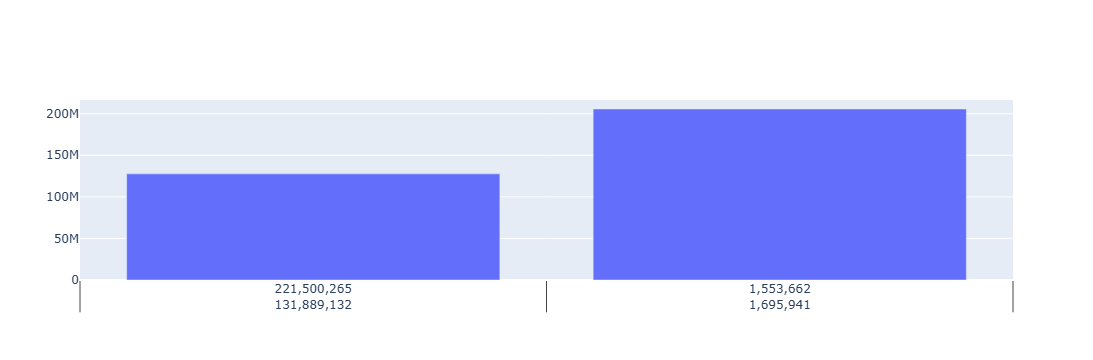

In [29]:
import plotly .graph_objects as go
fig = go.Figure([go.Bar(x=country[:10],y=new_case[:10])])
fig.show()

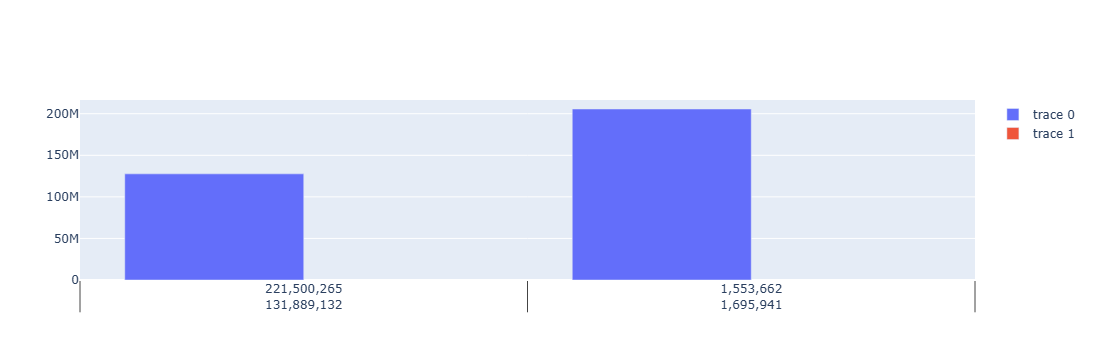

In [38]:
import plotly.graph_objects as go
fig=go.Figure(data=[
    go.Bar(x=country,y=new_case),
    go.Bar(x=country,y=total_recovered)
])
fig.show()